In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
png_train = pd.read_csv('./../../data/raw/png_train.csv')
png_valid = pd.read_csv('./../../data/raw/png_valid.csv')
df = pd.read_csv('./../../data/raw/df_chexpert_plus_240401.csv')

In [4]:
print(df.columns.tolist())
print(png_train.columns.tolist())
print(png_valid.columns.tolist())

['path_to_image', 'path_to_dcm', 'frontal_lateral', 'ap_pa', 'deid_patient_id', 'patient_report_date_order', 'report', 'section_narrative', 'section_clinical_history', 'section_history', 'section_comparison', 'section_technique', 'section_procedure_comments', 'section_findings', 'section_impression', 'section_end_of_impression', 'section_summary', 'section_accession_number', 'age', 'sex', 'race', 'ethnicity', 'interpreter_needed', 'insurance_type', 'recent_bmi', 'deceased', 'split']
['file_id', 'file_name', 'size', 'added_at', 'md5_hash']
['file_id', 'file_name', 'size', 'added_at', 'md5_hash']


In [5]:
png_df = pd.concat([png_train, png_valid], ignore_index=True)

In [6]:
df["merge_key"] = (
    df["path_to_image"]
    .str.replace(r"^(train|valid)/", "", regex=True)
    .str.replace(".jpg", ".png", regex=False)
)

matches = df["merge_key"].isin(png_df["file_name"]).sum()

print(matches)
print(len(df))

223462
223462


In [7]:
df = df.merge(
    png_df,
    left_on="merge_key",
    right_on="file_name",
    how="left"
)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 223462 entries, 0 to 223461
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223462 non-null  str    
 1   path_to_dcm                 223462 non-null  str    
 2   frontal_lateral             223462 non-null  str    
 3   ap_pa                       191071 non-null  str    
 4   deid_patient_id             223462 non-null  str    
 5   patient_report_date_order   223462 non-null  int64  
 6   report                      223462 non-null  str    
 7   section_narrative           223434 non-null  str    
 8   section_clinical_history    138866 non-null  str    
 9   section_history             38192 non-null   str    
 10  section_comparison          213125 non-null  str    
 11  section_technique           10732 non-null   str    
 12  section_procedure_comments  25669 non-null   str    
 13  section_findings         

In [9]:
df.isna().sum()

path_to_image                      0
path_to_dcm                        0
frontal_lateral                    0
ap_pa                          32391
deid_patient_id                    0
patient_report_date_order          0
report                             0
section_narrative                 28
section_clinical_history       84596
section_history               185270
section_comparison             10337
section_technique             212730
section_procedure_comments    197793
section_findings              163993
section_impression               145
section_end_of_impression     149724
section_summary                33814
section_accession_number           0
age                              278
sex                                0
race                               0
ethnicity                          0
interpreter_needed                 0
insurance_type                     0
recent_bmi                     58477
deceased                           0
split                              0
m

In [10]:
df.head(5)

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,insurance_type,recent_bmi,deceased,split,merge_key,file_id,file_name,size,added_at,md5_hash
0,train/patient00003/study1/view1_frontal.jpg,train/patient00003/study1/view1_frontal.dcm,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...","\nCHEST, ONE VIEW: 2-10-2001\n",NaN,NaN,...,Private Insurance,NaN,No,train,patient00003/study1/view1_frontal.png,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q,patient00003/study1/view1_frontal.png,3163254,2026-02-16 04:39:52.955,aGM1sAryZdWth1BEL8NHHA==
1,train/patient00007/study2/view1_frontal.jpg,train/patient00007/study2/view1_frontal.dcm,Frontal,AP,patient00007,2,NARRATIVE:\nChest 1 View: July 20\n \nHISTORY:...,\nChest 1 View: July 20\n \n,NaN,"Male, 69 years old, intubated.\n \n",...,Private Insurance,NaN,No,train,patient00007/study2/view1_frontal.png,s6cj-f5e10m11h.pcOrWX5YjfE9ZErtq-eJXQ,patient00007/study2/view1_frontal.png,3694667,2026-02-16 05:15:35.595,oMumQp5oW88Octdy5tvy6w==
2,train/patient00007/study1/view1_frontal.jpg,train/patient00007/study1/view1_frontal.dcm,Frontal,AP,patient00007,1,NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTO...,\nChest 1 View: 12-28-2000\n \n,NaN,"Male, 69 years old, Check tube placement.\n \n",...,Private Insurance,NaN,No,train,patient00007/study1/view1_frontal.png,s6cj-f5e10m11h.VAxaojvK0BvUxrJjJkohZw,patient00007/study1/view1_frontal.png,3946903,2026-02-16 05:15:35.595,VRRUV4ZMxZx4f/i7M1ljuQ==
3,train/patient00009/study1/view2_lateral.jpg,train/patient00009/study1/view2_lateral.dcm,Lateral,NaN,patient00009,1,NARRATIVE:\nCHEST X-RAY: 2/21/2006\nCOMPARISON...,\nCHEST X-RAY: 2/21/2006\n,Dyspnea. Multiple myeloma.\n,NaN,...,Medicare,NaN,No,train,patient00009/study1/view2_lateral.png,s6cj-f5e10m11h.1eb8X56bQZrFmuiDMOWIhA,patient00009/study1/view2_lateral.png,1496215,2026-02-16 03:50:47.231,VqB5pKN/c61NkaISxL7gFw==
4,train/patient00009/study1/view1_frontal.jpg,train/patient00009/study1/view1_frontal.dcm,Frontal,PA,patient00009,2,NARRATIVE:\nCHEST X-RAY: 4/27/07\nCOMPARISON: ...,\nCHEST X-RAY: 4/27/07\n,Dyspnea. Multiple myeloma.\n,NaN,...,Medicare,NaN,No,train,patient00009/study1/view1_frontal.png,s6cj-f5e10m11h.u5xhAj3Vsu2KbFl7GqNbbQ,patient00009/study1/view1_frontal.png,1624917,2026-02-16 03:50:47.231,sVZ8HG1W846zEANPSJPIpQ==


## Report = section_narrative + section_clinical_history + section_history + section_comparison + section_technique section_procedure_comments section_findings + section_impression + section_end_of_impression + section_summary + section_accession_number

In [11]:
columns_to_keep = ['frontal_lateral', 'ap_pa', 'deid_patient_id', 'patient_report_date_order', 'report', 'age', 'sex',
                   'race', 'ethnicity', 'recent_bmi', 'split', 'file_id']

In [12]:
df['interpreter_needed'].unique()

<ArrowStringArray>
['Unknown', 'No', 'Yes']
Length: 3, dtype: str

In [13]:
df['interpreter_needed'].value_counts(dropna=False)

interpreter_needed
No         165937
Unknown     39191
Yes         18334
Name: count, dtype: int64

In [14]:
df['deceased'].value_counts(dropna=False)

deceased
No         132037
Yes         91029
Unknown       396
Name: count, dtype: int64

In [15]:
df['recent_bmi'].value_counts(dropna=False).head()

recent_bmi
NaN     58477
50.0     1749
25.1     1532
24.4     1505
25.8     1488
Name: count, dtype: int64

In [16]:
clean_df = df[columns_to_keep].copy()

In [17]:
clean_df.isna().sum()

frontal_lateral                  0
ap_pa                        32391
deid_patient_id                  0
patient_report_date_order        0
report                           0
age                            278
sex                              0
race                             0
ethnicity                        0
recent_bmi                   58477
split                            0
file_id                          0
dtype: int64

In [18]:
# Calculate row-wise percentages
percentage_table = pd.crosstab(df['frontal_lateral'], df['ap_pa'], normalize='index') * 100
print(percentage_table)

ap_pa                   AP        LL         PA        RL
frontal_lateral                                          
Frontal          84.587405  0.008374  15.403698  0.000523


In [19]:
clean_df['frontal_lateral'].value_counts(dropna=False)

frontal_lateral
Frontal    191071
Lateral     32391
Name: count, dtype: int64

In [20]:
clean_df[('ap_pa')].value_counts(dropna=False)

ap_pa
AP     161622
NaN     32391
PA      29432
LL         16
RL          1
Name: count, dtype: int64

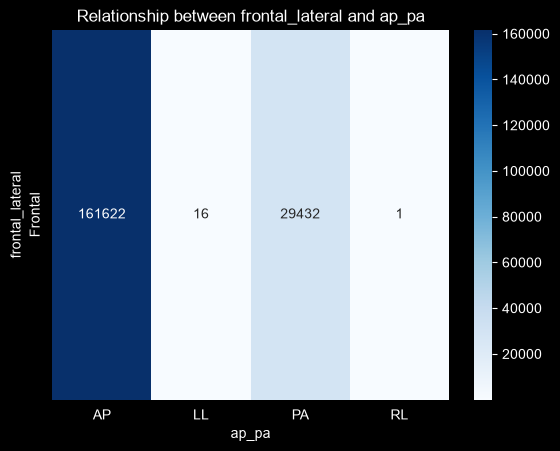

In [21]:
sns.heatmap(pd.crosstab(clean_df['frontal_lateral'], clean_df['ap_pa']), annot=True, fmt='d', cmap='Blues')
plt.title('Relationship between frontal_lateral and ap_pa')
plt.show()

In [22]:
clean_df.head()

,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,age,sex,race,ethnicity,recent_bmi,split,file_id
0,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",41.0,Male,White,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q
1,Frontal,AP,patient00007,2,NARRATIVE:\nChest 1 View: July 20\n \nHISTORY:...,69.0,Male,Other,Hispanic/Latino,NaN,train,s6cj-f5e10m11h.pcOrWX5YjfE9ZErtq-eJXQ
2,Frontal,AP,patient00007,1,NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTO...,69.0,Male,Other,Hispanic/Latino,NaN,train,s6cj-f5e10m11h.VAxaojvK0BvUxrJjJkohZw
3,Lateral,NaN,patient00009,1,NARRATIVE:\nCHEST X-RAY: 2/21/2006\nCOMPARISON...,76.0,Male,Asian,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.1eb8X56bQZrFmuiDMOWIhA
4,Frontal,PA,patient00009,2,NARRATIVE:\nCHEST X-RAY: 4/27/07\nCOMPARISON: ...,76.0,Male,Asian,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.u5xhAj3Vsu2KbFl7GqNbbQ


In [23]:
clean_df.loc[clean_df["frontal_lateral"] == "Lateral", "ap_pa"] = "LL"

In [24]:
bad_indices = clean_df[
    (clean_df["frontal_lateral"] == "Frontal") &
    (clean_df["ap_pa"] == "LL")
    ].index

In [25]:
clean_df.drop(index=bad_indices, inplace=True)

In [26]:
clean_df = clean_df[clean_df["ap_pa"] != "RL"]

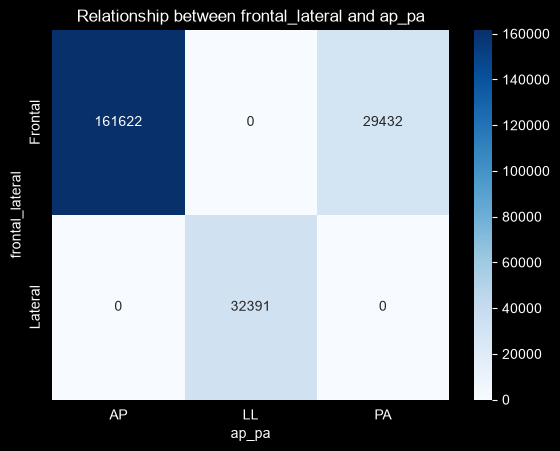

In [27]:
sns.heatmap(pd.crosstab(clean_df['frontal_lateral'], clean_df['ap_pa']), annot=True, fmt='d', cmap='Blues')
plt.title('Relationship between frontal_lateral and ap_pa')
plt.show()

In [28]:
clean_df.isna().sum()

frontal_lateral                  0
ap_pa                            0
deid_patient_id                  0
patient_report_date_order        0
report                           0
age                            278
sex                              0
race                             0
ethnicity                        0
recent_bmi                   58473
split                            0
file_id                          0
dtype: int64

In [29]:
clean_df.head()

,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,age,sex,race,ethnicity,recent_bmi,split,file_id
0,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",41.0,Male,White,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q
1,Frontal,AP,patient00007,2,NARRATIVE:\nChest 1 View: July 20\n \nHISTORY:...,69.0,Male,Other,Hispanic/Latino,NaN,train,s6cj-f5e10m11h.pcOrWX5YjfE9ZErtq-eJXQ
2,Frontal,AP,patient00007,1,NARRATIVE:\nChest 1 View: 12-28-2000\n \nHISTO...,69.0,Male,Other,Hispanic/Latino,NaN,train,s6cj-f5e10m11h.VAxaojvK0BvUxrJjJkohZw
3,Lateral,LL,patient00009,1,NARRATIVE:\nCHEST X-RAY: 2/21/2006\nCOMPARISON...,76.0,Male,Asian,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.1eb8X56bQZrFmuiDMOWIhA
4,Frontal,PA,patient00009,2,NARRATIVE:\nCHEST X-RAY: 4/27/07\nCOMPARISON: ...,76.0,Male,Asian,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.u5xhAj3Vsu2KbFl7GqNbbQ


# now our dataset is clean enough to train out vlm

In [30]:
clean_df = clean_df.sort_values(
    ["deid_patient_id", "patient_report_date_order"]
)

In [31]:
patients = df.groupby("deid_patient_id")

In [32]:
patients

In [33]:
import re


def clean_report(report):
    # Remove everything after ACCESSION NUMBER
    report = re.sub(
        r"ACCESSION NUMBER:.*",
        "",
        report,
        flags=re.DOTALL
    )

    # Remove END OF IMPRESSION
    report = re.sub(
        r"END OF IMPRESSION:",
        "",
        report
    )

    # Remove reviewer/signature paragraph
    report = re.sub(
        r"I have personally reviewed.*?By:.*",
        "",
        report,
        flags=re.DOTALL
    )

    return report.strip()

In [34]:
clean_df["report"] = clean_df["report"].apply(clean_report)

In [35]:
clean_df.head()

,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,age,sex,race,ethnicity,recent_bmi,split,file_id
219760,Frontal,AP,patient00001,1,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,68.0,Female,Other,Non-Hispanic/Non-Latino,44.2,train,s6cj-f5e10m11h.4MafEl-RrYhHLi2oPR7rSQ
82233,Frontal,AP,patient00002,1,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw
82234,Lateral,LL,patient00002,2,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Yanfzh9xHis7xBuRwHoJ9g
82235,Frontal,AP,patient00002,3,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 4 VIEWS ...",87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.GlbHOOej0uwxZ6mUkMuipw
0,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",41.0,Male,White,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q


In [36]:
clean_df = clean_df.sort_values(
    ["deid_patient_id", "patient_report_date_order"]
)

In [37]:
clean_df.head()

,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,age,sex,race,ethnicity,recent_bmi,split,file_id
219760,Frontal,AP,patient00001,1,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,68.0,Female,Other,Non-Hispanic/Non-Latino,44.2,train,s6cj-f5e10m11h.4MafEl-RrYhHLi2oPR7rSQ
82233,Frontal,AP,patient00002,1,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw
82234,Lateral,LL,patient00002,2,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Yanfzh9xHis7xBuRwHoJ9g
82235,Frontal,AP,patient00002,3,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 4 VIEWS ...",87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.GlbHOOej0uwxZ6mUkMuipw
0,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",41.0,Male,White,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q


In [38]:
clean_df = clean_df.reset_index(drop=True)

In [39]:
clean_df.head()

,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,age,sex,race,ethnicity,recent_bmi,split,file_id
0,Frontal,AP,patient00001,1,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,68.0,Female,Other,Non-Hispanic/Non-Latino,44.2,train,s6cj-f5e10m11h.4MafEl-RrYhHLi2oPR7rSQ
1,Frontal,AP,patient00002,1,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw
2,Lateral,LL,patient00002,2,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.Yanfzh9xHis7xBuRwHoJ9g
3,Frontal,AP,patient00002,3,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 4 VIEWS ...",87.0,Female,White,Non-Hispanic/Non-Latino,20.6,train,s6cj-f5e10m11h.GlbHOOej0uwxZ6mUkMuipw
4,Frontal,AP,patient00003,1,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",41.0,Male,White,Non-Hispanic/Non-Latino,NaN,train,s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q


In [40]:
def build_prompt(df, idx):
    current = df.iloc[idx]
    patient_id = current["deid_patient_id"]

    previous_reports = []
    image_file_ids = []

    # working backward through previous reports
    j = idx

    while j >= 0:
        row = df.iloc[j]

        # when patient changes - STOP
        if row["deid_patient_id"] != patient_id:
            break

        image_file_ids.append(row["file_id"])

        if j != idx:
            previous_reports.append(row["report"])

        j -= 1

    # reversing as we had gone backward
    previous_reports.reverse()
    image_file_ids.reverse()

    prompt = f"""You are an expert thoracic radiologist.

    PATIENT INFORMATION
    -------------------
    Age: {current["age"]}
    Sex: {current["sex"]}
    Projection: {current["ap_pa"]}
    View: {current["frontal_lateral"]}
    BMI: {current["recent_bmi"]}
    Race: {current["race"]}
    Ethnicity: {current["ethnicity"]}

    PREVIOUS REPORTS
    ----------------
    """

    for i, report in enumerate(previous_reports, start=1):
        prompt += f"\nStudy {i}\n"
        prompt += report
        prompt += "\n"

    prompt += """

        CURRENT TASK
        ------------
        Generate the radiology report for the LAST chest X-ray image.
        """

    return {
        "prompt": prompt,
        "image_file_ids": image_file_ids,
        "target_report": current["report"]
    }

In [41]:
prompts = []
image_lists = []

for i in range(len(clean_df)):
    example = build_prompt(clean_df, i)

    prompts.append(example["prompt"])
    image_lists.append(example["image_file_ids"])

clean_df["prompt"] = prompts
clean_df["image_file_ids"] = image_lists

In [45]:
clean_df.head()

,report,split,prompt,image_file_ids
0,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,train,You are an expert thoracic radiologist.\n\n ...,[s6cj-f5e10m11h.4MafEl-RrYhHLi2oPR7rSQ]
1,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,train,You are an expert thoracic radiologist.\n\n ...,[s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw]
2,NARRATIVE:\nFRONTAL AND LATERAL CHEST RADIOGRA...,train,You are an expert thoracic radiologist.\n\n ...,"[s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw, s6cj-f..."
3,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 4 VIEWS ...",train,You are an expert thoracic radiologist.\n\n ...,"[s6cj-f5e10m11h.Oc5LOGuATXu630N5amOXmw, s6cj-f..."
4,"NARRATIVE:\nCHEST, ONE VIEW: 2-10-2001\nFINDIN...",train,You are an expert thoracic radiologist.\n\n ...,[s6cj-f5e10m11h.kbtoHXjniUchFJPuxvqx3Q]


In [43]:
clean_df = clean_df.drop(['frontal_lateral','ap_pa', "deid_patient_id", "patient_report_date_order","age","sex","race","ethnicity", "recent_bmi","file_id"],axis = 1)

In [44]:
clean_df.to_csv("./../../data/processed/dataset.csv", index=False)
clean_df.to_parquet("./../../data/processed/dataset.parquet", index=False)

# So this marks the end of our data preprocessing it surely was an long task but its worth it at the end as its nearly 80% of the work on the ai part now i hopes it dose'nt take much long I have atleast five times came back to this notebook after closing this and thinking ITs done but finally now its **DONE**

# **THIS** Preprocessing included